In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv


# The Goal of This notebook is to use Machine Learning to Detect Fake News

## 1. EDA

### importing Libraries

In [2]:
import numpy as np
import pandas as pd
from matplotlib.pylab import plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec

### 1.1 Reading Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
Ratio of real and fake news:


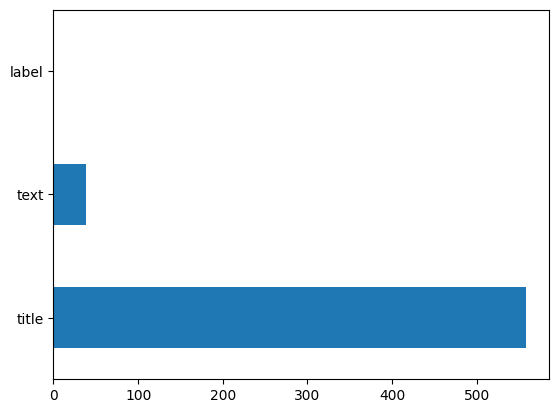

In [5]:
df = pd.read_csv('/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv')
df.head(10)
df.describe()
df.info()
y = df.label
print(f'Ratio of real and fake news:')
y.value_counts(normalize=True).rename({1: 'real', 0: 'fake'})
df.drop(["Unnamed: 0"], axis=1, inplace=True)
df.isnull().sum().plot(kind="barh")
plt.show()

Observations:
* There are a total of 4 columns and 72134 rows in the data
* Label is the target variable
* Percentage of Real and fake News articles: real : 51% fake :49%
* Missing values are present in the dataset

In [6]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [7]:
df = df.fillna('')
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [8]:
df.nunique()

title    62348
text     62719
label        2
dtype: int64

In [9]:
df["title_text"] = df["title"] + df["text"]
df["body_len"] = df["title_text"].apply(lambda x: len(x) - x.count(" "))
df.head()

,title,text,label,title_text,body_len
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,4222
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?,39
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,299
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri...",6811
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...,1668


In [11]:
bins = np.linspace(0, 200, 40)

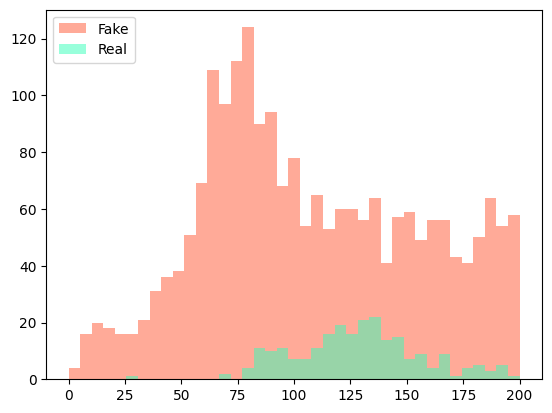

In [12]:
plt.hist(df[df["label"]== 1]["body_len"], bins, alpha=0.5, label="Fake", color="#FF5733")
plt.hist(df[df["label"]== 0]["body_len"], bins, alpha=0.5, label="Real", color="#33FFB8")
plt.legend(loc="upper left")
plt.show()

Insights : Fake news seem to be quite a bit longer than real news.

Text(0.5, 1.0, 'Distribution of Fake/Real News')

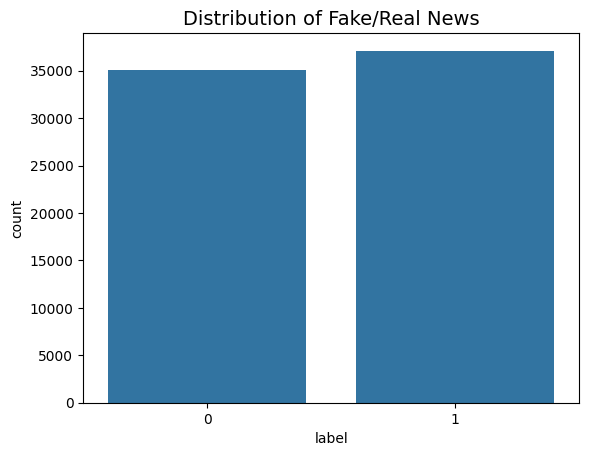

In [13]:

class_names = ['fake', 'real'] 
label_count = df.label.value_counts()
sns.barplot(x=label_count.index, y=label_count)
plt.title('Distribution of Fake/Real News',fontsize =14)



In [15]:
y.head()


0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], y, test_size=0.33, random_state=53)

### 1.2 Data Visualization of all News Titles

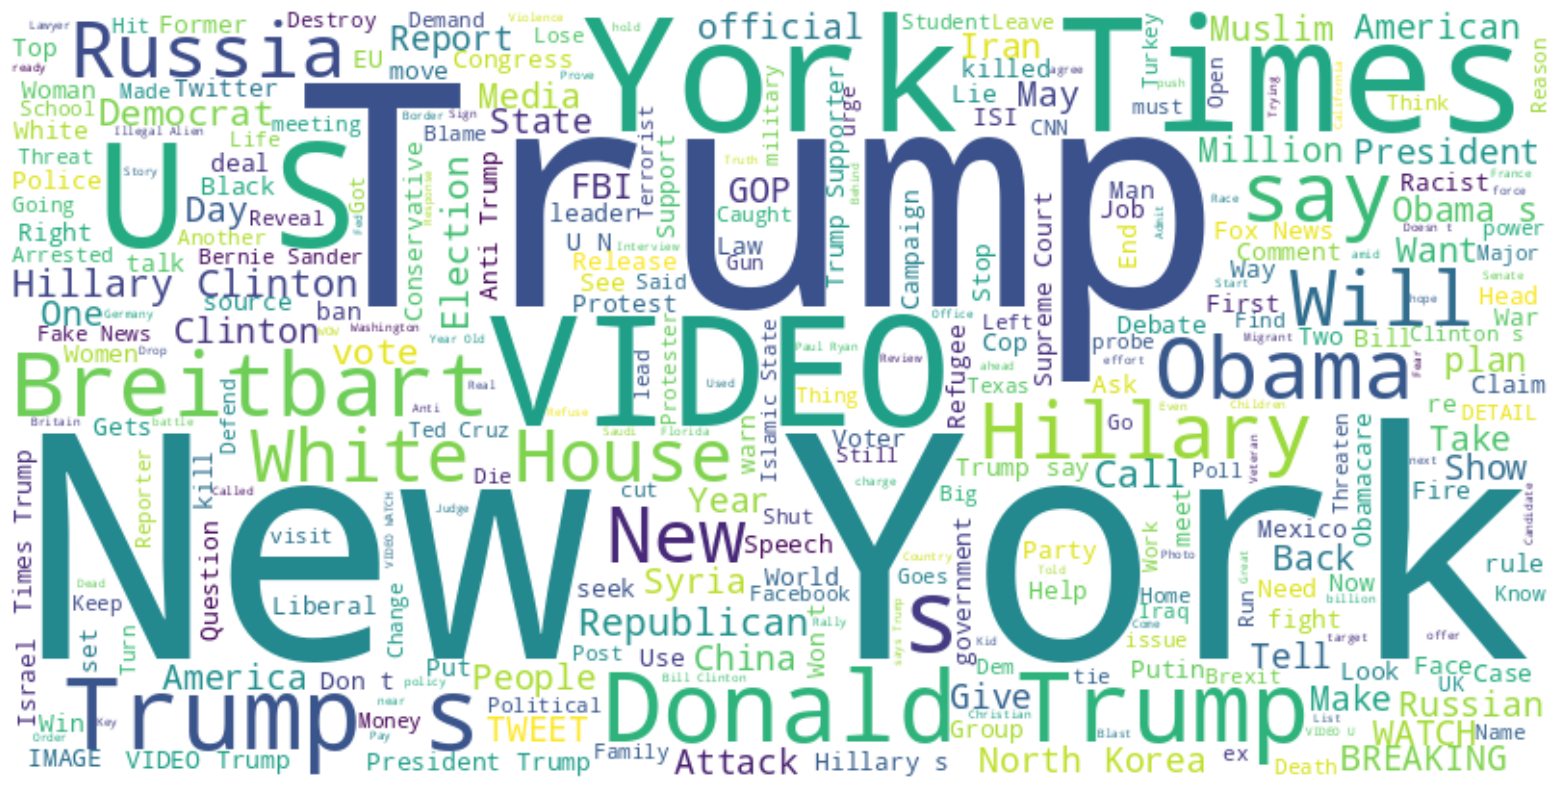

In [18]:
titles = ' '.join(title for title in df['title'])
wordcloud = WordCloud(
    background_color='white', 
    max_words=300,
    width=800, 
    height=400,
).generate(titles)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
Quick Insights: many of available news articles are about elections and presidents of USA plt.show()

Quick Insights: many of available news articles are about elections and presidents of USA 

### 1.3 Data Visualization of texts in fake news

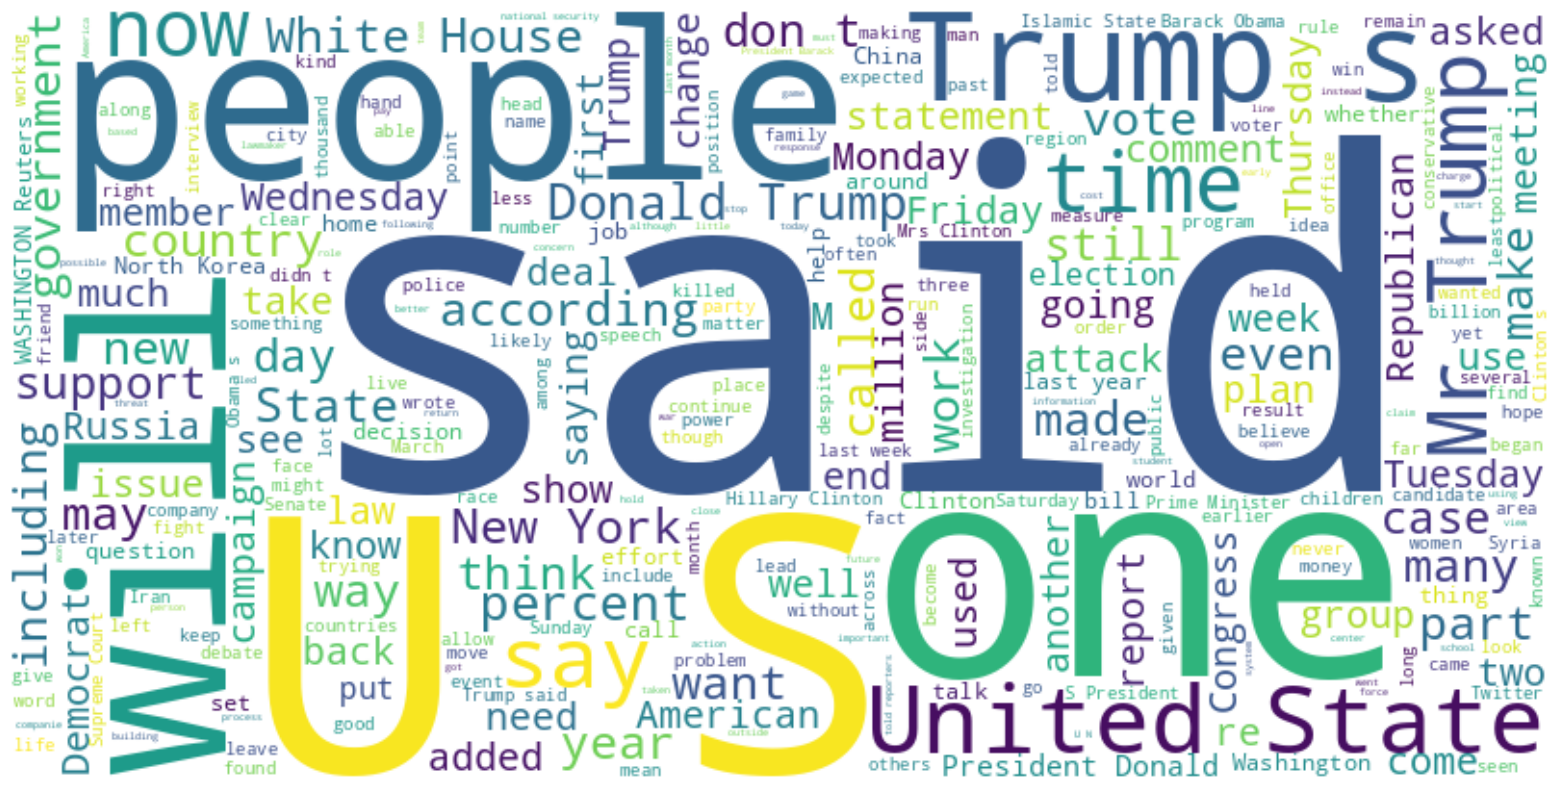

In [19]:
fake_news = X_train[y_train == 0]
real_news = X_train[y_train == 1]
fake_texts = ' '.join(text for text in fake_news)
wordcloud = WordCloud(
    background_color='white', 
    max_words=300,
    width=800, 
    height=400,
).generate(fake_texts)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### 1.4 Data Visualization of texts in Real news

<function matplotlib.pyplot.show(close=None, block=None)>

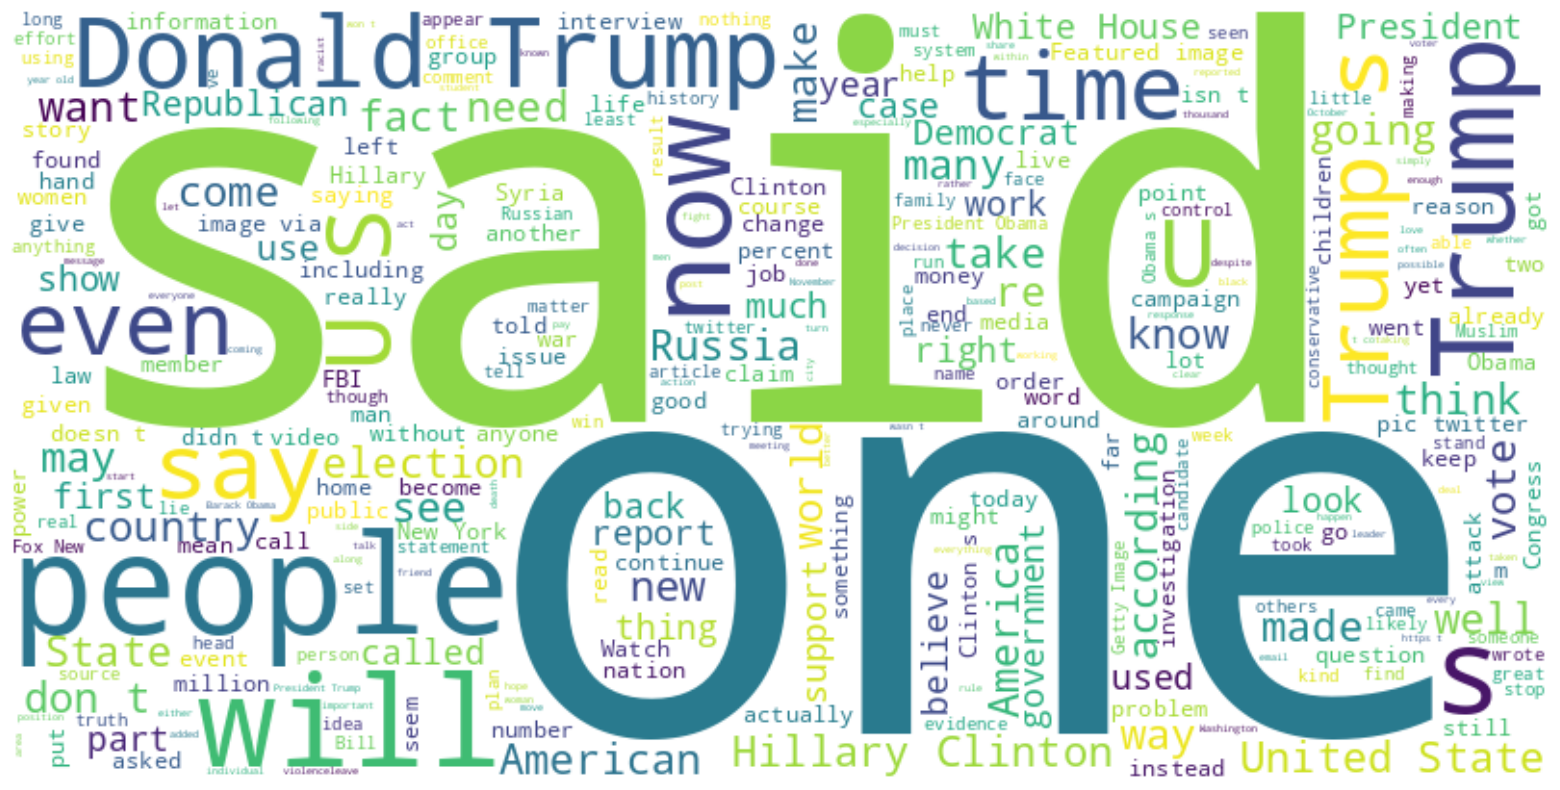

In [21]:
real_texts = ' '.join(text for text in real_news)
wordcloud = WordCloud(
    background_color='white', 
    max_words=300,
    width=800, 
    height=400,
).generate(real_texts)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show

## 2.Vectorization

In [22]:
# 1. Download necessary NLTK assets
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 2. Setup preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def pipeline_preprocess(text):
    # Tokenisation & Lowercasing
    tokens = word_tokenize(str(text).lower())
    # Stopword removal & Lemmatisation
    return [lemmatizer.lemmatize(w) for w in tokens if w.isalpha() and w not in stop_words]

# Apply preprocessing to train and test strings
X_train_tokens = [pipeline_preprocess(text) for text in X_train]
X_test_tokens = [pipeline_preprocess(text) for text in X_test]

# 3. Train Word2Vec model on the training tokens
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=2, workers=4)

# 4. Helper function to average word vectors into a single document vector
def document_vectorizer(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

# 5. Generate matching matrices for your downstream ML models
count_train = np.vstack([document_vectorizer(tokens, w2v_model) for tokens in X_train_tokens])
count_test = np.vstack([document_vectorizer(tokens, w2v_model) for tokens in X_test_tokens])

## 3. Training Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression()
lr_classifier.fit(count_train, y_train)

LogisticRegression()

### 3.1 Predictions on LR model

In [28]:
pred = lr_classifier.predict(count_test)

### 3.2 Evaluation of LR predictions

In [29]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87     11640
           1       0.87      0.88      0.88     12165

    accuracy                           0.88     23805
   macro avg       0.88      0.88      0.88     23805
weighted avg       0.88      0.88      0.88     23805



### 3.3 Confusion Matrix

Text(70.72222222222221, 0.5, 'Real Labels')

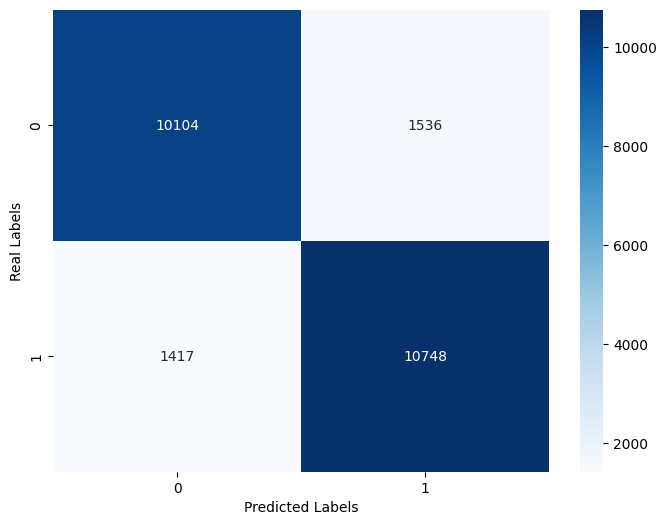

In [30]:
plt.figure(figsize = (8,6))

sns.heatmap(confusion_matrix(y_test,pred), annot=True, 
            fmt='', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('Real Labels')

## 4.Training Random Forest Model

In [31]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=300)
model.fit(count_train, y_train)

RandomForestClassifier(n_estimators=300)

## 4.1 Predictions on Random Forest Classifier

In [32]:
pred2 = model.predict(count_test)

## 4.2 Evaluation of RF Classifier Predictions

In [33]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89     11640
           1       0.88      0.93      0.90     12165

    accuracy                           0.90     23805
   macro avg       0.90      0.90      0.90     23805
weighted avg       0.90      0.90      0.90     23805



## 4.3 Confusion Matrix

Text(70.72222222222221, 0.5, 'Real Labels')

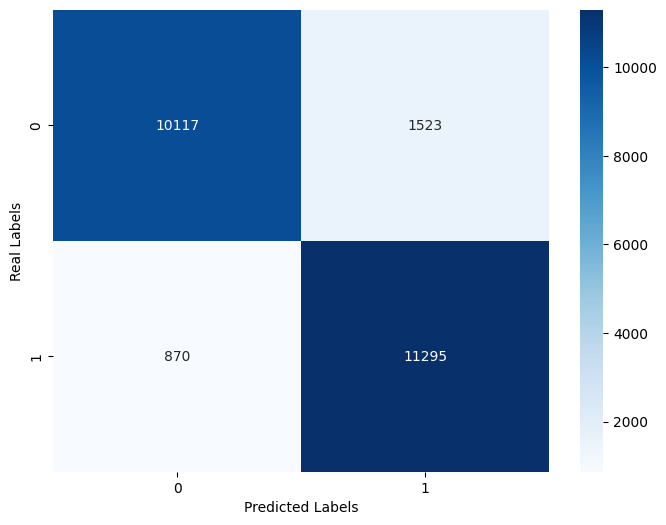

In [34]:
plt.figure(figsize = (8,6))

sns.heatmap(confusion_matrix(y_test,pred2), annot=True, 
            fmt='', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('Real Labels')